In [1]:
import pandas as pd

orders = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

print("Orders shape:", orders.shape)
print("Products shape:", products.shape)

Orders shape: (508, 11)
Products shape: (31, 5)


In [2]:
print("ORDER DATA INFORMATION")
orders.info()

print("\nORDER DATA SUMMARY")
display(orders.describe(include="all"))

print("\nORDER STATUS COUNTS")
print(orders["status"].value_counts(dropna=False))

print("\nFIRST 5 ORDER RECORDS")
display(orders.head())

ORDER DATA INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    str    
 2   customer_name  508 non-null    str    
 3   city           508 non-null    str    
 4   category       508 non-null    str    
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    str    
 9   status         508 non-null    str    
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), str(6)
memory usage: 43.8 KB

ORDER DATA SUMMARY


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
count,508.000000,508,508,508,508,508.000000,508.000000,498.000000,508,508,439.000000
unique,NaN,165,50,14,18,NaN,NaN,NaN,5,3,NaN
top,NaN,2026-04-16,Arjun,Mumbai,Household Essentials,NaN,NaN,NaN,Wallet,Delivered,NaN
freq,NaN,10,19,133,94,NaN,NaN,NaN,111,439,NaN
mean,250.204724,NaN,NaN,NaN,NaN,15.476378,3.045276,257.530120,NaN,NaN,3.082005
std,144.594139,NaN,NaN,NaN,NaN,8.747467,1.364497,559.424136,NaN,NaN,1.364126
min,1.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,20.000000,NaN,NaN,1.000000
25%,125.750000,NaN,NaN,NaN,NaN,8.000000,2.000000,90.000000,NaN,NaN,2.000000
50%,249.500000,NaN,NaN,NaN,NaN,15.000000,3.000000,168.000000,NaN,NaN,3.000000
75%,376.250000,NaN,NaN,NaN,NaN,23.000000,4.000000,283.750000,NaN,NaN,4.000000



ORDER STATUS COUNTS
status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64

FIRST 5 ORDER RECORDS


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0


In [3]:
print("DUPLICATE ORDER IDs")
print("Number of duplicated rows:", orders["order_id"].duplicated().sum())

print("\nNumber of unique order IDs:", orders["order_id"].nunique())

print("\nDuplicate order records:")
display(
    orders[orders["order_id"].duplicated(keep=False)]
    .sort_values("order_id")
)

DUPLICATE ORDER IDs
Number of duplicated rows: 8

Number of unique order IDs: 500

Duplicate order records:


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
49,50,2026-03-12,Sai,Hyderabad,Bakery,27,4,280.0,UPI,Delivered,2.0
507,50,2026-03-12,Sai,Hyderabad,Bakery,27,4,280.0,UPI,Delivered,2.0
503,102,2026-02-15,Kavya,Hyderabad,Dairy & Eggs,6,4,240.0,Wallet,Pending,NaN
101,102,2026-02-15,Kavya,Hyderabad,Dairy & Eggs,6,4,240.0,Wallet,Pending,NaN
135,136,2026-02-11,Rohan,Mumbai,Bakery,29,1,85.0,Debit Card,Delivered,4.0
506,136,2026-02-11,Rohan,Mumbai,Bakery,29,1,85.0,Debit Card,Delivered,4.0
501,139,2026-04-16,Vikram,Pune,Household Essentials,23,4,580.0,UPI,Delivered,3.0
138,139,2026-04-16,Vikram,Pune,Household Essentials,23,4,580.0,UPI,Delivered,3.0
500,165,2026-04-08,Aman,Pune,Fruits & Vegetables,5,2,50.0,Wallet,Delivered,3.0
164,165,2026-04-08,Aman,Pune,Fruits & Vegetables,5,2,50.0,Wallet,Delivered,3.0


In [4]:
# Remove duplicate orders
orders_clean = orders.drop_duplicates(subset="order_id", keep="first").copy()

print("Rows before removing duplicates:", len(orders))
print("Rows after removing duplicates:", len(orders_clean))
print("Unique order IDs:", orders_clean["order_id"].nunique())

Rows before removing duplicates: 508
Rows after removing duplicates: 500
Unique order IDs: 500


In [5]:
# Clean city and category text
orders_clean["city"] = orders_clean["city"].str.strip().str.title()
orders_clean["category"] = orders_clean["category"].str.strip().str.title()

print("Unique cities:")
print(sorted(orders_clean["city"].unique()))

print("\nNumber of unique cities:", orders_clean["city"].nunique())

print("\nUnique categories:")
print(sorted(orders_clean["category"].unique()))

print("\nNumber of unique categories:", orders_clean["category"].nunique())

Unique cities:
['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']

Number of unique cities: 4

Unique categories:
['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']

Number of unique categories: 6


In [6]:
# Check missing values after duplicate removal

print("Missing amount_inr values:", orders_clean["amount_inr"].isna().sum())

print("\nRows with missing amount_inr:")
display(
    orders_clean[orders_clean["amount_inr"].isna()]
)

Missing amount_inr values: 10

Rows with missing amount_inr:


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
33,34,2026-05-05,Myra,Bengaluru,Dairy & Eggs,7,4,NaN,Cash on Delivery,Delivered,4.0
35,36,2026-06-19,Riya,Pune,Personal Care,18,5,NaN,Cash on Delivery,Delivered,3.0
113,114,2026-06-02,Shreya,Pune,Household Essentials,25,5,NaN,Debit Card,Pending,NaN
231,232,2026-02-08,Divya,Pune,Personal Care,20,5,NaN,UPI,Delivered,3.0
268,269,2026-01-10,Nikhil,Pune,Personal Care,20,3,NaN,Credit Card,Delivered,1.0
287,288,2026-04-05,Yash,Bengaluru,Household Essentials,23,5,NaN,Cash on Delivery,Delivered,5.0
304,305,2026-02-18,Rohan,Mumbai,Household Essentials,25,3,NaN,Credit Card,Delivered,5.0
332,333,2026-06-21,Myra,Bengaluru,Dairy & Eggs,10,1,NaN,Wallet,Delivered,2.0
365,366,2026-06-07,Aditya,Pune,Bakery,29,4,NaN,UPI,Delivered,1.0
414,415,2026-05-22,Vivaan,Hyderabad,Fruits & Vegetables,3,3,NaN,UPI,Delivered,3.0


In [7]:
# Record missing amount information

missing_amount_count = orders_clean["amount_inr"].isna().sum()
missing_amount_delivered = orders_clean.loc[
    (orders_clean["status"] == "Delivered") &
    (orders_clean["amount_inr"].isna())
].shape[0]

print("Total missing amount_inr values:", missing_amount_count)
print("Missing amount_inr among Delivered orders:", missing_amount_delivered)
print("Missing amount_inr values will be excluded from revenue calculations.")

Total missing amount_inr values: 10
Missing amount_inr among Delivered orders: 9
Missing amount_inr values will be excluded from revenue calculations.


In [8]:
# Calculate IQR-based outlier threshold for Delivered revenue

delivered_amounts = orders_clean.loc[
    (orders_clean["status"] == "Delivered") &
    (orders_clean["amount_inr"].notna()),
    "amount_inr"
]

Q1 = delivered_amounts.quantile(0.25)
Q3 = delivered_amounts.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + (1.5 * IQR)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper fence:", upper_fence)

print("\nMaximum Delivered amount:", delivered_amounts.max())

print(
    "Number of Delivered amounts above upper fence:",
    (delivered_amounts > upper_fence).sum()
)

Q1: 90.0
Q3: 275.0
IQR: 185.0
Upper fence: 552.5

Maximum Delivered amount: 7600.0
Number of Delivered amounts above upper fence: 16


In [9]:
# Cap extreme Delivered amounts at the IQR upper fence

orders_clean["amount_capped"] = orders_clean["amount_inr"].copy()

delivered_mask = orders_clean["status"] == "Delivered"

orders_clean.loc[delivered_mask, "amount_capped"] = (
    orders_clean.loc[delivered_mask, "amount_inr"]
    .clip(upper=upper_fence)
)

# Count how many values were capped
capped_count = (
    (orders_clean["amount_inr"] > upper_fence) &
    (orders_clean["status"] == "Delivered")
).sum()

print("Upper fence used for capping:", upper_fence)
print("Number of Delivered amounts capped:", capped_count)

print("\nLargest amounts before capping:")
print(
    orders_clean.loc[
        delivered_mask & orders_clean["amount_inr"].notna(),
        "amount_inr"
    ].nlargest(10).to_list()
)

print("\nLargest amounts after capping:")
print(
    orders_clean.loc[
        delivered_mask & orders_clean["amount_capped"].notna(),
        "amount_capped"
    ].nlargest(10).to_list()
)

Upper fence used for capping: 552.5
Number of Delivered amounts capped: 16

Largest amounts before capping:
[7600.0, 5400.0, 5200.0, 1100.0, 900.0, 720.0, 660.0, 650.0, 650.0, 600.0]

Largest amounts after capping:
[552.5, 552.5, 552.5, 552.5, 552.5, 552.5, 552.5, 552.5, 552.5, 552.5]


In [10]:
# Create date and time-based fields

orders_clean["order_date"] = pd.to_datetime(orders_clean["order_date"])

orders_clean["month"] = orders_clean["order_date"].dt.to_period("M").astype(str)

orders_clean["month_name"] = orders_clean["order_date"].dt.strftime("%B")

# Revenue per unit using the capped amount
orders_clean["revenue_per_unit"] = (
    orders_clean["amount_capped"] / orders_clean["quantity"]
)

# Flag Delivered orders
orders_clean["is_delivered"] = orders_clean["status"].eq("Delivered")

print("Date range:", orders_clean["order_date"].min(), "to", orders_clean["order_date"].max())

print("\nMonths present:")
print(sorted(orders_clean["month"].unique()))

print("\nMonth names:")
print(orders_clean["month_name"].unique())

print("\nDelivered orders:", orders_clean["is_delivered"].sum())

print("\nSample of new fields:")
display(
    orders_clean[
        [
            "order_date",
            "month",
            "month_name",
            "quantity",
            "amount_capped",
            "revenue_per_unit",
            "is_delivered"
        ]
    ].head()
)

Date range: 2026-01-01 00:00:00 to 2026-06-30 00:00:00

Months present:
['2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06']

Month names:
<StringArray>
['March', 'May', 'June', 'April', 'January', 'February']
Length: 6, dtype: str

Delivered orders: 434

Sample of new fields:


,order_date,month,month_name,quantity,amount_capped,revenue_per_unit,is_delivered
0,2026-03-09,2026-03,March,5,175.0,35.0,True
1,2026-05-22,2026-05,May,1,60.0,60.0,True
2,2026-06-30,2026-06,June,2,150.0,75.0,True
3,2026-03-01,2026-03,March,1,30.0,30.0,True
4,2026-04-05,2026-04,April,2,220.0,110.0,True


In [11]:
# Delivered revenue by category

delivered_category_revenue = (
    orders_clean[
        (orders_clean["is_delivered"]) &
        (orders_clean["amount_capped"].notna())
    ]
    .groupby("category", as_index=False)["amount_capped"]
    .sum()
    .rename(columns={"amount_capped": "delivered_revenue"})
    .sort_values("delivered_revenue", ascending=False)
)

print("Delivered revenue by category:")
display(delivered_category_revenue)

print(
    "\nTop category by delivered revenue:",
    delivered_category_revenue.iloc[0]["category"]
)

print(
    "Top category revenue:",
    delivered_category_revenue.iloc[0]["delivered_revenue"]
)

Delivered revenue by category:


,category,delivered_revenue
3,Household Essentials,20910.0
0,Bakery,14975.0
4,Personal Care,14594.5
1,Dairy & Eggs,13675.0
5,Snacks & Beverages,11312.5
2,Fruits & Vegetables,9170.0



Top category by delivered revenue: Household Essentials
Top category revenue: 20910.0


In [12]:
# Merge cleaned orders with product information

orders_products = orders_clean.merge(
    products[["product_id", "supplier"]],
    on="product_id",
    how="left"
)

print("Merged data shape:", orders_products.shape)

print("\nMissing supplier values:")
print(orders_products["supplier"].isna().sum())

print("\nSample of merged data:")
display(
    orders_products[
        [
            "order_id",
            "product_id",
            "category",
            "supplier",
            "amount_capped",
            "status"
        ]
    ].head()
)

Merged data shape: (500, 17)

Missing supplier values:
0

Sample of merged data:


,order_id,product_id,category,supplier,amount_capped,status
0,1,13,Snacks & Beverages,BakeHouse Supplies,175.0,Delivered
1,2,15,Snacks & Beverages,BakeHouse Supplies,60.0,Delivered
2,3,25,Household Essentials,HomeEssentials Traders,150.0,Delivered
3,4,11,Snacks & Beverages,SnackHub India,30.0,Delivered
4,5,14,Snacks & Beverages,SnackHub India,220.0,Delivered


In [13]:
# Delivered revenue by supplier

delivered_supplier_revenue = (
    orders_products[
        (orders_products["is_delivered"]) &
        (orders_products["amount_capped"].notna())
    ]
    .groupby("supplier", as_index=False)["amount_capped"]
    .sum()
    .rename(columns={"amount_capped": "delivered_revenue"})
    .sort_values("delivered_revenue", ascending=False)
)

print("Delivered revenue by supplier:")
display(delivered_supplier_revenue)

print(
    "\nTop supplier by delivered revenue:",
    delivered_supplier_revenue.iloc[0]["supplier"]
)

print(
    "Top supplier revenue:",
    delivered_supplier_revenue.iloc[0]["delivered_revenue"]
)

Delivered revenue by supplier:


,supplier,delivered_revenue
6,HomeEssentials Traders,20910.0
0,BakeHouse Supplies,18550.0
1,CarePlus Distributors,14594.5
3,DairyBest Ltd,10710.0
7,SnackHub India,7737.5
4,FreshFarms Co,5490.0
5,GreenValley Traders,3680.0
2,CountryEggs Farms,2965.0



Top supplier by delivered revenue: HomeEssentials Traders
Top supplier revenue: 20910.0


In [14]:
# Cross-validation with Part 1 results

python_top_category = delivered_category_revenue.iloc[0]["category"]
python_top_supplier = delivered_supplier_revenue.iloc[0]["supplier"]

# Part 1 SQL results from the connected analysis
sql_top_category = "Household Essentials"
sql_top_supplier = "HomeEssentials Traders"

print("CROSS-VALIDATION RESULTS")
print("=" * 50)

print("Python top category:", python_top_category)
print("Part 1 SQL top category:", sql_top_category)
print(
    "Category match:",
    python_top_category == sql_top_category
)

print()

print("Python top supplier:", python_top_supplier)
print("Part 1 SQL top supplier:", sql_top_supplier)
print(
    "Supplier match:",
    python_top_supplier == sql_top_supplier
)

print()

if (
    python_top_category == sql_top_category
    and python_top_supplier == sql_top_supplier
):
    print("RESULT: Both Python results match Part 1.")
else:
    print("RESULT: Review the cross-validation results.")

CROSS-VALIDATION RESULTS
Python top category: Household Essentials
Part 1 SQL top category: Household Essentials
Category match: True

Python top supplier: HomeEssentials Traders
Part 1 SQL top supplier: HomeEssentials Traders
Supplier match: True

RESULT: Both Python results match Part 1.


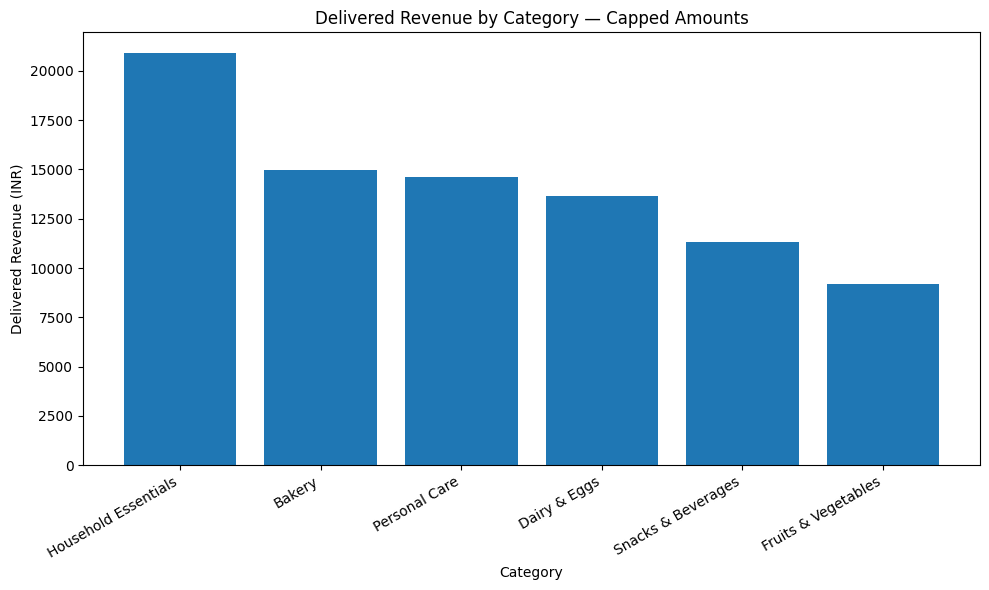

In [15]:
import matplotlib.pyplot as plt

# Chart 1: Delivered revenue by category

category_chart = (
    orders_clean[orders_clean["is_delivered"] & orders_clean["amount_capped"].notna()]
    .groupby("category", as_index=False)["amount_capped"]
    .sum()
    .sort_values("amount_capped", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(category_chart["category"], category_chart["amount_capped"])
plt.title("Delivered Revenue by Category — Capped Amounts")
plt.xlabel("Category")
plt.ylabel("Delivered Revenue (INR)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

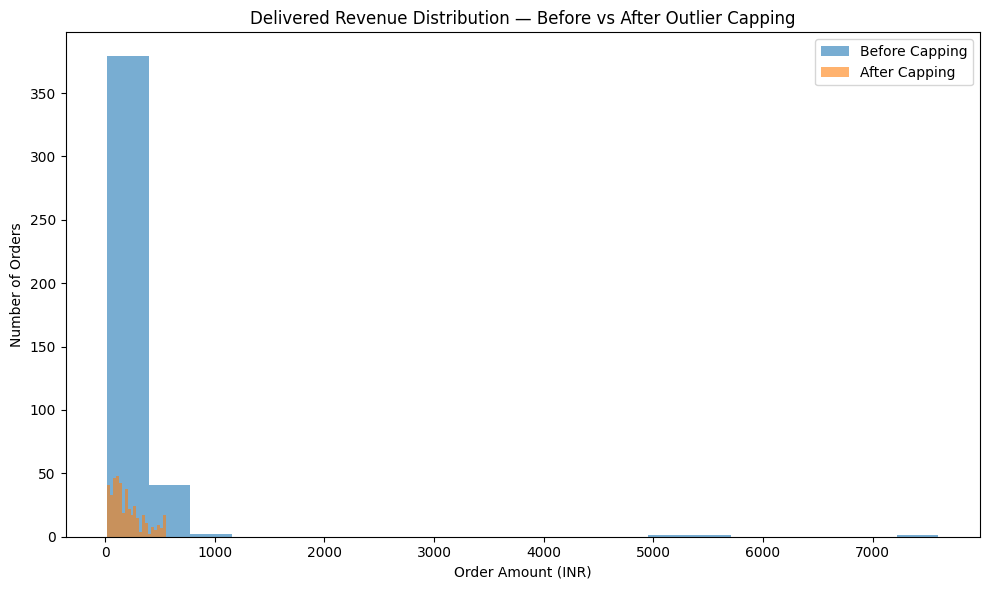

In [16]:
# Chart 2: Delivered revenue distribution before and after capping

plt.figure(figsize=(10, 6))

delivered_before = orders_clean.loc[
    orders_clean["is_delivered"] & orders_clean["amount_inr"].notna(),
    "amount_inr"
]

delivered_after = orders_clean.loc[
    orders_clean["is_delivered"] & orders_clean["amount_capped"].notna(),
    "amount_capped"
]

plt.hist(delivered_before, bins=20, alpha=0.6, label="Before Capping")
plt.hist(delivered_after, bins=20, alpha=0.6, label="After Capping")

plt.title("Delivered Revenue Distribution — Before vs After Outlier Capping")
plt.xlabel("Order Amount (INR)")
plt.ylabel("Number of Orders")
plt.legend()
plt.tight_layout()
plt.show()

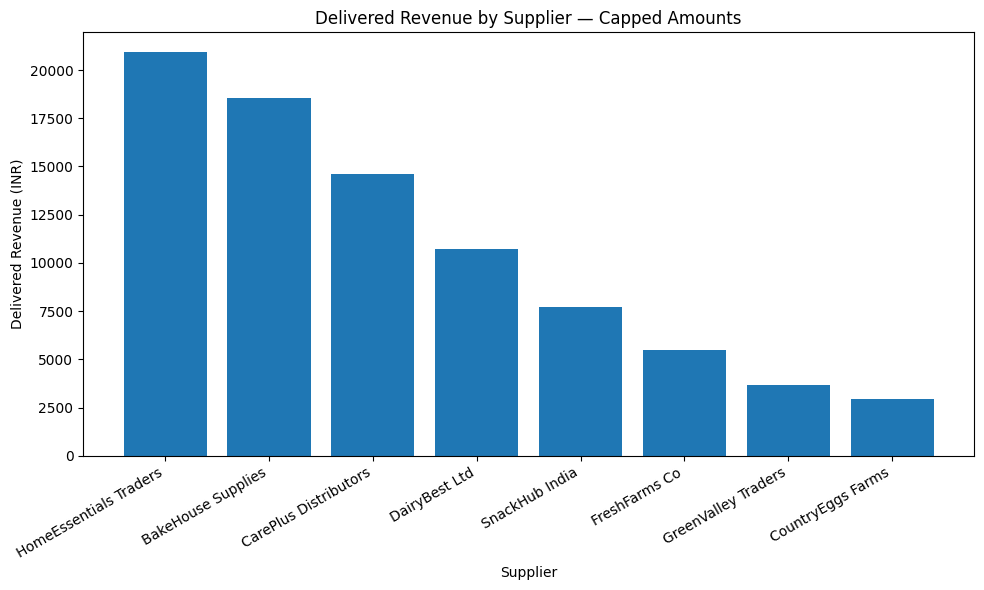

In [17]:
# Chart 3: Delivered revenue by supplier

supplier_chart = (
    delivered_supplier_revenue
    .sort_values("delivered_revenue", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(supplier_chart["supplier"], supplier_chart["delivered_revenue"])

plt.title("Delivered Revenue by Supplier — Capped Amounts")
plt.xlabel("Supplier")
plt.ylabel("Delivered Revenue (INR)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Key Observations — What, Why, Next Step

### 1. Household Essentials is the strongest category
**What:** Household Essentials generated the highest delivered revenue after outlier capping, at ₹20,910.

**Why:** Its delivered revenue is higher than every other category, indicating that this category contributes the most to overall delivered sales in the cleaned dataset.

**Next step:** BigBasket should examine the products and suppliers within Household Essentials to identify which items are driving this performance and consider maintaining strong availability for them.

### 2. HomeEssentials Traders is the top supplier
**What:** HomeEssentials Traders recorded the highest delivered revenue among suppliers, at ₹20,910.

**Why:** The supplier's revenue matches the top category's delivered revenue because its products are associated with the strongest-performing Household Essentials category.

**Next step:** BigBasket should review the supplier's product availability and delivery performance and consider prioritising high-performing products supplied by this vendor.

### 3. Extreme order amounts significantly affect the raw data
**What:** The raw dataset contained 16 Delivered order amounts above the IQR upper fence of ₹552.50, with the maximum reaching ₹7,600.

**Why:** These unusually large values can disproportionately increase revenue totals and make category or supplier performance appear stronger than the typical order pattern.

**Next step:** Future analysis should continue to flag and investigate extreme transactions while retaining the original values separately from the capped analytical values.